# DriftGuard — Code-Aware Transformer Training

This notebook fine-tunes a code-pretrained Transformer for configuration-drift
risk classification.

The model receives only raw change information:

- Field path
- Previous value
- New value
- Configuration type
- Operation
- Parser mode
- File path
- Commit message

It does not receive:

- Security-rule identifiers
- Weak-label explanations
- Weak-label confidence
- Repository identity
- Commit hashes
- Validation or test repositories

Training uses the temporal model-training partition. Evaluation uses the
commit-disjoint temporal development partition.

The primary model-selection metric is macro F1. Critical recall and combined
high/critical recall remain mandatory safety metrics.

In [1]:
import sys
import torch

print("Python executable :", sys.executable)
print("PyTorch version   :", torch.__version__)
print("CUDA build        :", torch.version.cuda)
print("CUDA available    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name          :", torch.cuda.get_device_name(0))
    print(
        "GPU memory        :",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )
else:
    print("GPU not detected by this notebook kernel.")

Python executable : C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
PyTorch version   : 2.11.0+cu128
CUDA build        : 12.8
CUDA available    : True
GPU name          : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory        : 6.00 GB


In [2]:
import importlib.util
import subprocess
import sys

required_packages = {
    "transformers": "transformers",
    "datasets": "datasets",
    "accelerate": "accelerate",
    "safetensors": "safetensors",
}

missing_packages = [
    pip_name
    for import_name, pip_name
    in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print(
        "Installing missing packages:",
        missing_packages,
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            *missing_packages,
        ]
    )

    print(
        "\nPackages installed."
        "\nRestart the kernel only if the next cell fails to import them."
    )
else:
    print("All required Transformer packages are already installed.")

All required Transformer packages are already installed.


In [3]:
import os
import sys
import json
import math
import time
import random
import inspect
import warnings
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import dataclass

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

import sklearn
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed,
)

import datasets
from datasets import Dataset


print("=" * 72)
print("DRIFTGUARD — CODE-AWARE TRANSFORMER TRAINING")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"

BASELINE_OUTPUT_DIR = (
    PROJECT_ROOT / "outputs" / "baseline_models"
)

STRUCTURED_OUTPUT_DIR = (
    PROJECT_ROOT / "outputs" / "structured_models"
)

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT / "models" / "transformer"
)

CHECKPOINT_DIR = (
    MODEL_OUTPUT_DIR / "checkpoints"
)

BEST_MODEL_DIR = (
    MODEL_OUTPUT_DIR / "best_codeberta_model"
)

OUTPUTS_DIR = (
    PROJECT_ROOT / "outputs" / "transformer_model"
)

TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
LOGS_DIR = OUTPUTS_DIR / "logs"
CONFIGS_DIR = PROJECT_ROOT / "configs"

for directory in [
    MODEL_OUTPUT_DIR,
    CHECKPOINT_DIR,
    BEST_MODEL_DIR,
    OUTPUTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings("default")

print("Python version       :", sys.version.split()[0])
print("PyTorch version      :", torch.__version__)
print("Transformers version :", transformers.__version__)
print("Datasets version     :", datasets.__version__)
print("Scikit-learn version :", sklearn.__version__)
print("Python executable    :", sys.executable)
print("Conda environment    :", os.environ.get("CONDA_DEFAULT_ENV", "Not detected"))
print("Project root        :", PROJECT_ROOT)

DRIFTGUARD — CODE-AWARE TRANSFORMER TRAINING
Python version       : 3.11.15
PyTorch version      : 2.11.0+cu128
Transformers version : 5.14.1
Datasets version     : 5.0.0
Scikit-learn version : 1.9.0
Python executable    : C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
Conda environment    : driftguard
Project root        : C:\Users\Lenovo\Desktop\DriftGuard


In [4]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
set_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Random seed:", RANDOM_SEED)

Random seed: 42


In [5]:
CUDA_AVAILABLE = torch.cuda.is_available()

if CUDA_AVAILABLE:
    DEVICE_NAME = torch.cuda.get_device_name(0)

    GPU_MEMORY_GB = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    if GPU_MEMORY_GB < 7:
        TRAIN_BATCH_SIZE = 2
        EVALUATION_BATCH_SIZE = 8
        GRADIENT_ACCUMULATION_STEPS = 8

    elif GPU_MEMORY_GB < 10:
        TRAIN_BATCH_SIZE = 4
        EVALUATION_BATCH_SIZE = 8
        GRADIENT_ACCUMULATION_STEPS = 4

    else:
        TRAIN_BATCH_SIZE = 8
        EVALUATION_BATCH_SIZE = 16
        GRADIENT_ACCUMULATION_STEPS = 2

else:
    DEVICE_NAME = "CPU"
    GPU_MEMORY_GB = 0.0

    TRAIN_BATCH_SIZE = 4
    EVALUATION_BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 4

EFFECTIVE_BATCH_SIZE = (
    TRAIN_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)

USE_FP16 = CUDA_AVAILABLE
USE_GRADIENT_CHECKPOINTING = CUDA_AVAILABLE

print("CUDA available              :", CUDA_AVAILABLE)
print("Device                      :", DEVICE_NAME)
print("GPU memory                  :", f"{GPU_MEMORY_GB:.2f} GB")
print("Training batch size         :", TRAIN_BATCH_SIZE)
print("Evaluation batch size       :", EVALUATION_BATCH_SIZE)
print("Gradient accumulation steps :", GRADIENT_ACCUMULATION_STEPS)
print("Effective training batch    :", EFFECTIVE_BATCH_SIZE)
print("FP16                        :", USE_FP16)
print("Gradient checkpointing      :", USE_GRADIENT_CHECKPOINTING)

CUDA available              : True
Device                      : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory                  : 6.00 GB
Training batch size         : 2
Evaluation batch size       : 8
Gradient accumulation steps : 8
Effective training batch    : 16
FP16                        : True
Gradient checkpointing      : True


In [6]:
TRANSFORMER_SETTINGS = {
    "random_seed": RANDOM_SEED,

    "pretrained_model_name": (
        "huggingface/CodeBERTa-small-v1"
    ),

    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "maximum_sequence_length": 256,

    "maximum_field_path_characters": 1_000,
    "maximum_old_value_characters": 1_500,
    "maximum_new_value_characters": 1_500,
    "maximum_file_path_characters": 1_000,
    "maximum_commit_message_characters": 800,

    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "number_of_epochs": 5,
    "warmup_ratio": 0.10,

    "training_batch_size": TRAIN_BATCH_SIZE,
    "evaluation_batch_size": EVALUATION_BATCH_SIZE,

    "gradient_accumulation_steps": (
        GRADIENT_ACCUMULATION_STEPS
    ),

    "early_stopping_patience": 2,
    "early_stopping_threshold": 0.001,

    "maximum_gradient_norm": 1.0,

    "metric_for_best_model": "macro_f1",

    "additional_special_tokens": [
        "[FIELD]",
        "[OLD]",
        "[NEW]",
        "[CONFIG_TYPE]",
        "[OPERATION]",
        "[PARSER]",
        "[FILE]",
        "[COMMIT]",
    ],
}

CLASS_ORDER = TRANSFORMER_SETTINGS[
    "class_order"
]

MAXIMUM_SEQUENCE_LENGTH = (
    TRANSFORMER_SETTINGS[
        "maximum_sequence_length"
    ]
)

transformer_settings_path = (
    CONFIGS_DIR
    / "transformer_training_settings.json"
)

with transformer_settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        TRANSFORMER_SETTINGS,
        file,
        indent=2,
    )

print(
    json.dumps(
        TRANSFORMER_SETTINGS,
        indent=2,
    )
)

print(
    "\nSaved settings:",
    transformer_settings_path,
)

{
  "random_seed": 42,
  "pretrained_model_name": "huggingface/CodeBERTa-small-v1",
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "maximum_sequence_length": 256,
  "maximum_field_path_characters": 1000,
  "maximum_old_value_characters": 1500,
  "maximum_new_value_characters": 1500,
  "maximum_file_path_characters": 1000,
  "maximum_commit_message_characters": 800,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "number_of_epochs": 5,
  "warmup_ratio": 0.1,
  "training_batch_size": 2,
  "evaluation_batch_size": 8,
  "gradient_accumulation_steps": 8,
  "early_stopping_patience": 2,
  "early_stopping_threshold": 0.001,
  "maximum_gradient_norm": 1.0,
  "metric_for_best_model": "macro_f1",
  "additional_special_tokens": [
    "[FIELD]",
    "[OLD]",
    "[NEW]",
    "[CONFIG_TYPE]",
    "[OPERATION]",
    "[PARSER]",
    "[FILE]",
    "[COMMIT]"
  ]
}

Saved settings: C:\Users\Lenovo\Desktop\DriftGuard\configs\transformer_training_settings.

In [7]:
model_training_path = (
    CLEAN_DATA_DIR
    / "train_temporal_model_train.csv.gz"
)

temporal_development_path = (
    CLEAN_DATA_DIR
    / "train_temporal_development.csv.gz"
)

if not model_training_path.exists():
    raise FileNotFoundError(
        f"Missing training data:\n{model_training_path}"
    )

if not temporal_development_path.exists():
    raise FileNotFoundError(
        "Missing temporal-development data:\n"
        f"{temporal_development_path}"
    )

model_training_data = pd.read_csv(
    model_training_path,
    compression="gzip",
    low_memory=False,
)

temporal_development_data = pd.read_csv(
    temporal_development_path,
    compression="gzip",
    low_memory=False,
)

print(
    "Model-training records:",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-development records:",
    f"{len(temporal_development_data):,}",
)

Model-training records: 7,711
Temporal-development records: 1,865


In [8]:
REQUIRED_COLUMNS = [
    "diff_id",
    "repository",
    "commit_hash",
    "commit_author_date",
    "commit_message",
    "file_path",
    "configuration_type",
    "parser_mode",
    "operation",
    "field_path",
    "old_value",
    "new_value",
    "training_target",
    "sample_weight",
    "temporal_partition",
]

missing_training_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(model_training_data.columns)
)

missing_development_columns = sorted(
    set(REQUIRED_COLUMNS)
    - set(temporal_development_data.columns)
)

if missing_training_columns:
    raise ValueError(
        "Training dataset is missing columns:\n"
        + "\n".join(
            missing_training_columns
        )
    )

if missing_development_columns:
    raise ValueError(
        "Development dataset is missing columns:\n"
        + "\n".join(
            missing_development_columns
        )
    )

print("Required-column validation: PASSED")

Required-column validation: PASSED


In [9]:
for dataframe in [
    model_training_data,
    temporal_development_data,
]:
    dataframe["training_target"] = (
        dataframe["training_target"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    dataframe["sample_weight"] = pd.to_numeric(
        dataframe["sample_weight"],
        errors="coerce",
    )

    dataframe["commit_author_datetime"] = pd.to_datetime(
        dataframe["commit_author_date"],
        errors="coerce",
        utc=True,
    )

invalid_training_labels = (
    ~model_training_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

invalid_development_labels = (
    ~temporal_development_data[
        "training_target"
    ].isin(CLASS_ORDER)
)

if invalid_training_labels.any():
    raise ValueError(
        "Invalid model-training labels were found."
    )

if invalid_development_labels.any():
    raise ValueError(
        "Invalid temporal-development labels were found."
    )

if model_training_data[
    "sample_weight"
].isna().any():
    raise ValueError(
        "Training sample weights contain missing values."
    )

if (
    model_training_data[
        "sample_weight"
    ] <= 0
).any():
    raise ValueError(
        "Training sample weights must be positive."
    )

print("Label and weight validation: PASSED")

Label and weight validation: PASSED


In [10]:
training_commit_keys = set(
    zip(
        model_training_data[
            "repository"
        ],
        model_training_data[
            "commit_hash"
        ],
    )
)

development_commit_keys = set(
    zip(
        temporal_development_data[
            "repository"
        ],
        temporal_development_data[
            "commit_hash"
        ],
    )
)

overlapping_commit_keys = (
    training_commit_keys
    & development_commit_keys
)

print(
    "Model-training commits:",
    f"{len(training_commit_keys):,}",
)

print(
    "Temporal-development commits:",
    f"{len(development_commit_keys):,}",
)

print(
    "Overlapping commits:",
    f"{len(overlapping_commit_keys):,}",
)

if overlapping_commit_keys:
    raise ValueError(
        "Temporal commit leakage was detected."
    )

print("Temporal commit separation: PASSED")

Model-training commits: 1,058
Temporal-development commits: 266
Overlapping commits: 0
Temporal commit separation: PASSED


In [11]:
FORBIDDEN_FEATURE_COLUMNS = {
    "repository",
    "dataset_split",
    "commit_hash",
    "commit_author_date",
    "commit_author_datetime",
    "diff_id",
    "source_record_id",
    "change_signature_sha256",

    "weak_label",
    "weak_label_confidence",
    "severity_rank",
    "primary_rule_id",
    "matched_rule_ids",
    "matched_rule_count",
    "rule_conflict",
    "weak_label_reason",
    "label_source",
    "label_usage",
    "sensitive_terms",
    "sensitive_term_count",
    "needs_manual_review",

    "training_label_source",
    "training_target",
    "class_weight",
    "label_reliability_weight",
    "parser_reliability_weight",
    "conflict_reliability_weight",
    "sample_weight",
    "temporal_partition",
}

TRANSFORMER_RAW_FEATURE_COLUMNS = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "operation",
    "parser_mode",
    "file_path",
    "commit_message",
]

feature_leakage_overlap = (
    set(TRANSFORMER_RAW_FEATURE_COLUMNS)
    & FORBIDDEN_FEATURE_COLUMNS
)

print(
    "Transformer input columns:",
    TRANSFORMER_RAW_FEATURE_COLUMNS,
)

print(
    "Leakage overlap:",
    feature_leakage_overlap,
)

if feature_leakage_overlap:
    raise ValueError(
        "A forbidden leakage column was selected."
    )

print("Feature leakage check: PASSED")

Transformer input columns: ['field_path', 'old_value', 'new_value', 'configuration_type', 'operation', 'parser_mode', 'file_path', 'commit_message']
Leakage overlap: set()
Feature leakage check: PASSED


In [12]:
LABEL_TO_ID = {
    label: index
    for index, label
    in enumerate(CLASS_ORDER)
}

ID_TO_LABEL = {
    index: label
    for label, index
    in LABEL_TO_ID.items()
}

print("Label to ID:")
print(LABEL_TO_ID)

print("\nID to label:")
print(ID_TO_LABEL)

Label to ID:
{'benign': 0, 'low': 1, 'medium': 2, 'high': 3, 'critical': 4}

ID to label:
{0: 'benign', 1: 'low', 2: 'medium', 3: 'high', 4: 'critical'}


In [13]:
def normalize_text_value(
    value,
    maximum_characters,
):
    if pd.isna(value):
        return "<MISSING>"

    text = str(value)

    text = (
        text
        .replace("\r", " ")
        .replace("\n", " ")
        .replace("\t", " ")
    )

    text = " ".join(
        text.split()
    )

    if not text:
        return "<EMPTY>"

    return text[
        :maximum_characters
    ]


def build_transformer_text(
    dataframe,
):
    generated_text = []

    for record in dataframe[
        TRANSFORMER_RAW_FEATURE_COLUMNS
    ].to_dict(orient="records"):

        field_path = normalize_text_value(
            record.get("field_path"),
            TRANSFORMER_SETTINGS[
                "maximum_field_path_characters"
            ],
        )

        old_value = normalize_text_value(
            record.get("old_value"),
            TRANSFORMER_SETTINGS[
                "maximum_old_value_characters"
            ],
        )

        new_value = normalize_text_value(
            record.get("new_value"),
            TRANSFORMER_SETTINGS[
                "maximum_new_value_characters"
            ],
        )

        configuration_type = normalize_text_value(
            record.get("configuration_type"),
            200,
        )

        operation = normalize_text_value(
            record.get("operation"),
            100,
        )

        parser_mode = normalize_text_value(
            record.get("parser_mode"),
            100,
        )

        file_path = normalize_text_value(
            record.get("file_path"),
            TRANSFORMER_SETTINGS[
                "maximum_file_path_characters"
            ],
        )

        commit_message = normalize_text_value(
            record.get("commit_message"),
            TRANSFORMER_SETTINGS[
                "maximum_commit_message_characters"
            ],
        )

        combined_text = (
            f"[FIELD] {field_path} "
            f"[OLD] {old_value} "
            f"[NEW] {new_value} "
            f"[CONFIG_TYPE] {configuration_type} "
            f"[OPERATION] {operation} "
            f"[PARSER] {parser_mode} "
            f"[FILE] {file_path} "
            f"[COMMIT] {commit_message}"
        )

        generated_text.append(
            combined_text
        )

    return pd.Series(
        generated_text,
        index=dataframe.index,
        dtype="string",
    )


training_text = build_transformer_text(
    model_training_data
)

development_text = build_transformer_text(
    temporal_development_data
)

print(
    "Training text records:",
    f"{len(training_text):,}",
)

print(
    "Development text records:",
    f"{len(development_text):,}",
)

print(
    "Mean training characters:",
    f"{training_text.str.len().mean():.2f}",
)

print(
    "Maximum training characters:",
    f"{training_text.str.len().max():,}",
)

Training text records: 7,711
Development text records: 1,865
Mean training characters: 413.56
Maximum training characters: 1,836


In [14]:
pd.set_option(
    "display.max_colwidth",
    1_000,
)

transformer_text_preview = pd.DataFrame(
    {
        "target": model_training_data[
            "training_target"
        ].head(5),
        "transformer_text": training_text.head(5),
    }
)

display(
    transformer_text_preview
)

,target,transformer_text
0,high,"[FIELD] $.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.initContainers.items.properties.securityContext.properties.windowsOptions.properties.hostProcess.description [OLD] <MISSING> [NEW] HostProcess determines if a container should be run as a 'Host Process' container. This field is alpha-level and will only be honored by components that enable the WindowsHostProcessContainers feature flag. Setting this field without the feature flag will result in errors when validating the Pod. All of a Pod's containers must have the same effective HostProcess value (it is not allowed to have a mix of HostProcess containers and non-HostProcess containers). In addition, if HostProcess is true then HostNetwork must also be set to true. [CONFIG_TYPE] yaml [OPERATION] added [PARSER] structured [FILE] manifests/setup/prometheus-operator-0prometheusCustomResourceDefinition.yaml [COMMIT] [bot] [main] Automated version update"
1,benign,[FIELD] $.documents[0].spec.template.spec.containers[0].readinessProbe.httpGet.httpHeaders[0].name [OLD] Cookie [NEW] <MISSING> [CONFIG_TYPE] kubernetes [OPERATION] deleted [PARSER] structured [FILE] release/kubernetes-manifests.yaml [COMMIT] Release v0.2.0 (#331)
2,benign,[FIELD] $.documents[15].spec.template.spec.containers[0].env[1].name [OLD] USERS [NEW] <MISSING> [CONFIG_TYPE] kustomize [OPERATION] deleted [PARSER] structured [FILE] kustomize/base/kubernetes-manifests.yaml [COMMIT] Release v0.4.0 (#1135)
3,low,[FIELD] $.resources[37] [OLD] ./manifests/prometheus-adapter-roleBindingAuthReader.yaml [NEW] ./manifests/prometheus-adapter-configMap.yaml [CONFIG_TYPE] kustomize [OPERATION] modified [PARSER] structured [FILE] kustomization.yaml [COMMIT] set up authorization for blackbox-exporter
4,benign,"[FIELD] $.terraform[0].required_providers[0].version[0] [OLD] ""5.31.1"" [NEW] ""5.32.0"" [CONFIG_TYPE] terraform [OPERATION] modified [PARSER] structured [FILE] terraform/providers.tf [COMMIT] chore(deps): update terraform google to v5.32.0 (#2593)"


In [15]:
training_weight_mean = float(
    model_training_data[
        "sample_weight"
    ].mean()
)

if training_weight_mean <= 0:
    raise ValueError(
        "The mean training sample weight must be positive."
    )

normalized_training_weights = (
    model_training_data[
        "sample_weight"
    ].astype(float)
    / training_weight_mean
)

development_weight_mean = float(
    temporal_development_data[
        "sample_weight"
    ].mean()
)

normalized_development_weights = (
    temporal_development_data[
        "sample_weight"
    ].astype(float)
    / max(
        development_weight_mean,
        1e-12,
    )
)

weight_summary = pd.DataFrame(
    [
        {
            "partition": "model_train",
            "records": len(
                normalized_training_weights
            ),
            "mean": normalized_training_weights.mean(),
            "median": normalized_training_weights.median(),
            "minimum": normalized_training_weights.min(),
            "maximum": normalized_training_weights.max(),
        },
        {
            "partition": "temporal_dev",
            "records": len(
                normalized_development_weights
            ),
            "mean": normalized_development_weights.mean(),
            "median": normalized_development_weights.median(),
            "minimum": normalized_development_weights.min(),
            "maximum": normalized_development_weights.max(),
        },
    ]
)

display(weight_summary)

,partition,records,mean,median,minimum,maximum
0,model_train,7711,1.0,0.136207,0.136207,6.530103
1,temporal_dev,1865,1.0,0.156619,0.156619,7.508724


In [16]:
training_dataset = Dataset.from_dict(
    {
        "text": training_text.tolist(),

        "labels": [
            LABEL_TO_ID[label]
            for label
            in model_training_data[
                "training_target"
            ].astype(str)
        ],

        "sample_weight": (
            normalized_training_weights
            .astype(float)
            .tolist()
        ),
    }
)

development_dataset = Dataset.from_dict(
    {
        "text": development_text.tolist(),

        "labels": [
            LABEL_TO_ID[label]
            for label
            in temporal_development_data[
                "training_target"
            ].astype(str)
        ],

        "sample_weight": (
            normalized_development_weights
            .astype(float)
            .tolist()
        ),
    }
)

print(training_dataset)
print(development_dataset)

Dataset({
    features: ['text', 'labels', 'sample_weight'],
    num_rows: 7711
})
Dataset({
    features: ['text', 'labels', 'sample_weight'],
    num_rows: 1865
})


In [17]:
PRETRAINED_MODEL_NAME = (
    TRANSFORMER_SETTINGS[
        "pretrained_model_name"
    ]
)

tokenizer = AutoTokenizer.from_pretrained(
    PRETRAINED_MODEL_NAME,
    use_fast=True,
)

added_token_count = tokenizer.add_special_tokens(
    {
        "additional_special_tokens": (
            TRANSFORMER_SETTINGS[
                "additional_special_tokens"
            ]
        )
    }
)

print("Tokenizer:", PRETRAINED_MODEL_NAME)
print("Tokenizer vocabulary:", len(tokenizer))
print("Added special tokens:", added_token_count)
print("Model maximum length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--huggingface--CodeBERTa-small-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/994k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/483k [00:00<?, ?B/s]

Tokenizer: huggingface/CodeBERTa-small-v1
Tokenizer vocabulary: 52008
Added special tokens: 8
Model maximum length: 512


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\transformers\models\roberta\tokenization_roberta.py:144: DeprecationWarning: Deprecated in 0.9.0: BPE.__init__ will not create from files anymore, try `BPE.from_file` instead
  BPE(


In [18]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAXIMUM_SEQUENCE_LENGTH,
        padding=False,
    )


tokenization_start = time.perf_counter()

tokenized_training_dataset = (
    training_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc="Tokenizing model-training data",
    )
)

tokenized_development_dataset = (
    development_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"],
        desc="Tokenizing temporal-development data",
    )
)

tokenization_seconds = (
    time.perf_counter()
    - tokenization_start
)

print(
    "Tokenization seconds:",
    f"{tokenization_seconds:.2f}",
)

print(tokenized_training_dataset)
print(tokenized_development_dataset)

Tokenizing model-training data:   0%|          | 0/7711 [00:00<?, ? examples/s]

Tokenizing temporal-development data:   0%|          | 0/1865 [00:00<?, ? examples/s]

Tokenization seconds: 1.56
Dataset({
    features: ['labels', 'sample_weight', 'input_ids', 'attention_mask'],
    num_rows: 7711
})
Dataset({
    features: ['labels', 'sample_weight', 'input_ids', 'attention_mask'],
    num_rows: 1865
})


In [19]:
training_token_lengths = np.asarray(
    [
        len(input_ids)
        for input_ids
        in tokenized_training_dataset[
            "input_ids"
        ]
    ],
    dtype=int,
)

development_token_lengths = np.asarray(
    [
        len(input_ids)
        for input_ids
        in tokenized_development_dataset[
            "input_ids"
        ]
    ],
    dtype=int,
)

token_length_summary = pd.DataFrame(
    [
        {
            "partition": "model_train",
            "records": len(
                training_token_lengths
            ),
            "mean_tokens": float(
                training_token_lengths.mean()
            ),
            "median_tokens": float(
                np.median(
                    training_token_lengths
                )
            ),
            "p95_tokens": float(
                np.percentile(
                    training_token_lengths,
                    95,
                )
            ),
            "maximum_tokens": int(
                training_token_lengths.max()
            ),
            "maximum_length_records": int(
                (
                    training_token_lengths
                    >= MAXIMUM_SEQUENCE_LENGTH
                ).sum()
            ),
        },
        {
            "partition": "temporal_dev",
            "records": len(
                development_token_lengths
            ),
            "mean_tokens": float(
                development_token_lengths.mean()
            ),
            "median_tokens": float(
                np.median(
                    development_token_lengths
                )
            ),
            "p95_tokens": float(
                np.percentile(
                    development_token_lengths,
                    95,
                )
            ),
            "maximum_tokens": int(
                development_token_lengths.max()
            ),
            "maximum_length_records": int(
                (
                    development_token_lengths
                    >= MAXIMUM_SEQUENCE_LENGTH
                ).sum()
            ),
        },
    ]
)

display(token_length_summary)

token_length_summary.to_csv(
    TABLES_DIR
    / "transformer_token_length_summary.csv",
    index=False,
)

,partition,records,mean_tokens,median_tokens,p95_tokens,maximum_tokens,maximum_length_records
0,model_train,7711,106.649981,85.0,256.0,256,483
1,temporal_dev,1865,119.690080,110.0,231.8,256,81


In [20]:
@dataclass
class WeightedDataCollator:
    tokenizer: object

    def __post_init__(self):
        self.padding_collator = (
            DataCollatorWithPadding(
                tokenizer=self.tokenizer,
                padding=True,
                return_tensors="pt",
            )
        )

    def __call__(self, features):
        copied_features = [
            dict(feature)
            for feature in features
        ]

        labels = [
            int(
                feature.pop("labels")
            )
            for feature in copied_features
        ]

        sample_weights = [
            float(
                feature.pop(
                    "sample_weight",
                    1.0,
                )
            )
            for feature in copied_features
        ]

        batch = self.padding_collator(
            copied_features
        )

        batch["labels"] = torch.tensor(
            labels,
            dtype=torch.long,
        )

        batch["sample_weight"] = torch.tensor(
            sample_weights,
            dtype=torch.float32,
        )

        return batch


weighted_data_collator = (
    WeightedDataCollator(
        tokenizer=tokenizer
    )
)

test_batch = weighted_data_collator(
    [
        tokenized_training_dataset[0],
        tokenized_training_dataset[1],
    ]
)

print(
    {
        key: tuple(value.shape)
        for key, value
        in test_batch.items()
    }
)

{'input_ids': (2, 197), 'attention_mask': (2, 197), 'labels': (2,), 'sample_weight': (2,)}


In [21]:
def softmax_numpy(logits):
    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float32,
    )

    return (
        torch.softmax(
            logits_tensor,
            dim=1,
        )
        .cpu()
        .numpy()
    )


def calculate_binary_risk_metrics(
    true_labels,
    predicted_labels,
    positive_label_ids,
):
    true_binary = np.isin(
        true_labels,
        positive_label_ids,
    ).astype(int)

    predicted_binary = np.isin(
        predicted_labels,
        positive_label_ids,
    ).astype(int)

    return {
        "precision": float(
            precision_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
    }


def calculate_macro_average_precision(
    true_label_ids,
    probability_matrix,
):
    average_precision_values = []

    for class_index in range(
        len(CLASS_ORDER)
    ):
        binary_target = (
            np.asarray(
                true_label_ids
            )
            == class_index
        ).astype(int)

        positive_count = int(
            binary_target.sum()
        )

        negative_count = int(
            len(binary_target)
            - positive_count
        )

        if (
            positive_count == 0
            or negative_count == 0
        ):
            continue

        average_precision_values.append(
            average_precision_score(
                binary_target,
                probability_matrix[
                    :,
                    class_index,
                ],
            )
        )

    if not average_precision_values:
        return np.nan

    return float(
        np.mean(
            average_precision_values
        )
    )

In [22]:
def compute_transformer_metrics(
    evaluation_prediction,
):
    logits = evaluation_prediction.predictions
    true_label_ids = evaluation_prediction.label_ids

    if isinstance(logits, tuple):
        logits = logits[0]

    probability_matrix = softmax_numpy(
        logits
    )

    predicted_label_ids = np.argmax(
        probability_matrix,
        axis=1,
    )

    critical_id = LABEL_TO_ID[
        "critical"
    ]

    high_id = LABEL_TO_ID[
        "high"
    ]

    critical_metrics = (
        calculate_binary_risk_metrics(
            true_labels=true_label_ids,
            predicted_labels=predicted_label_ids,
            positive_label_ids=[
                critical_id,
            ],
        )
    )

    high_critical_metrics = (
        calculate_binary_risk_metrics(
            true_labels=true_label_ids,
            predicted_labels=predicted_label_ids,
            positive_label_ids=[
                high_id,
                critical_id,
            ],
        )
    )

    macro_pr_auc = (
        calculate_macro_average_precision(
            true_label_ids=true_label_ids,
            probability_matrix=(
                probability_matrix
            ),
        )
    )

    return {
        "accuracy": float(
            accuracy_score(
                true_label_ids,
                predicted_label_ids,
            )
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                true_label_ids,
                predicted_label_ids,
            )
        ),

        "macro_precision": float(
            precision_score(
                true_label_ids,
                predicted_label_ids,
                labels=list(
                    range(
                        len(CLASS_ORDER)
                    )
                ),
                average="macro",
                zero_division=0,
            )
        ),

        "macro_recall": float(
            recall_score(
                true_label_ids,
                predicted_label_ids,
                labels=list(
                    range(
                        len(CLASS_ORDER)
                    )
                ),
                average="macro",
                zero_division=0,
            )
        ),

        "macro_f1": float(
            f1_score(
                true_label_ids,
                predicted_label_ids,
                labels=list(
                    range(
                        len(CLASS_ORDER)
                    )
                ),
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": float(
            f1_score(
                true_label_ids,
                predicted_label_ids,
                labels=list(
                    range(
                        len(CLASS_ORDER)
                    )
                ),
                average="weighted",
                zero_division=0,
            )
        ),

        "macro_pr_auc": macro_pr_auc,

        "critical_precision":
            critical_metrics[
                "precision"
            ],

        "critical_recall":
            critical_metrics[
                "recall"
            ],

        "critical_f1":
            critical_metrics[
                "f1"
            ],

        "high_critical_precision":
            high_critical_metrics[
                "precision"
            ],

        "high_critical_recall":
            high_critical_metrics[
                "recall"
            ],

        "high_critical_f1":
            high_critical_metrics[
                "f1"
            ],
    }


print("Transformer metric function loaded.")

Transformer metric function loaded.


In [23]:
class SampleWeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop(
            "labels"
        )

        sample_weight = inputs.pop(
            "sample_weight",
            None,
        )

        outputs = model(
            **inputs
        )

        logits = outputs.logits

        per_record_loss = F.cross_entropy(
            logits,
            labels,
            reduction="none",
        )

        if sample_weight is not None:
            sample_weight = sample_weight.to(
                device=per_record_loss.device,
                dtype=per_record_loss.dtype,
            )

            loss = (
                per_record_loss
                * sample_weight
            ).sum() / sample_weight.sum().clamp(
                min=1e-12
            )

        else:
            loss = per_record_loss.mean()

        if return_outputs:
            return loss, outputs

        return loss


print("Sample-weighted Trainer loaded.")

Sample-weighted Trainer loaded.


In [24]:
transformer_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        PRETRAINED_MODEL_NAME,
        num_labels=len(
            CLASS_ORDER
        ),
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    )
)

transformer_model.resize_token_embeddings(
    len(tokenizer)
)

transformer_model.config.problem_type = (
    "single_label_classification"
)

if hasattr(
    transformer_model.config,
    "use_cache",
):
    transformer_model.config.use_cache = False

total_parameters = sum(
    parameter.numel()
    for parameter
    in transformer_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in transformer_model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters:",
    f"{total_parameters:,}",
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}",
)

print(
    "Number of labels:",
    transformer_model.config.num_labels,
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  336MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d740455080>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d740455a20>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d7404d90f0>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d740455160>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed soc

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: huggingface/CodeBERTa-small-v1
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream t

Total parameters: 83,460,869
Trainable parameters: 83,460,869
Number of labels: 5


In [25]:
training_argument_parameters = (
    inspect.signature(
        TrainingArguments.__init__
    ).parameters
)

training_argument_values = {
    "output_dir": str(
        CHECKPOINT_DIR
    ),

    "learning_rate": (
        TRANSFORMER_SETTINGS[
            "learning_rate"
        ]
    ),

    "per_device_train_batch_size": (
        TRANSFORMER_SETTINGS[
            "training_batch_size"
        ]
    ),

    "per_device_eval_batch_size": (
        TRANSFORMER_SETTINGS[
            "evaluation_batch_size"
        ]
    ),

    "gradient_accumulation_steps": (
        TRANSFORMER_SETTINGS[
            "gradient_accumulation_steps"
        ]
    ),

    "num_train_epochs": (
        TRANSFORMER_SETTINGS[
            "number_of_epochs"
        ]
    ),

    "weight_decay": (
        TRANSFORMER_SETTINGS[
            "weight_decay"
        ]
    ),

    "warmup_ratio": (
        TRANSFORMER_SETTINGS[
            "warmup_ratio"
        ]
    ),

    "max_grad_norm": (
        TRANSFORMER_SETTINGS[
            "maximum_gradient_norm"
        ]
    ),

    "save_strategy": "epoch",
    "logging_strategy": "steps",
    "logging_steps": 25,

    "load_best_model_at_end": True,

    "metric_for_best_model": (
        TRANSFORMER_SETTINGS[
            "metric_for_best_model"
        ]
    ),

    "greater_is_better": True,

    "save_total_limit": 2,

    "fp16": USE_FP16,
    "bf16": False,

    "gradient_checkpointing": (
        USE_GRADIENT_CHECKPOINTING
    ),

    "dataloader_num_workers": 0,

    "dataloader_pin_memory": (
        CUDA_AVAILABLE
    ),

    "remove_unused_columns": False,

    "report_to": "none",

    "seed": RANDOM_SEED,
    "data_seed": RANDOM_SEED,

    "run_name": (
        "driftguard-codeberta-temporal"
    ),

    "optim": "adamw_torch",
}

if (
    "eval_strategy"
    in training_argument_parameters
):
    training_argument_values[
        "eval_strategy"
    ] = "epoch"

elif (
    "evaluation_strategy"
    in training_argument_parameters
):
    training_argument_values[
        "evaluation_strategy"
    ] = "epoch"

else:
    raise RuntimeError(
        "This Transformers version does not expose "
        "eval_strategy or evaluation_strategy."
    )

supported_training_arguments = {
    key: value
    for key, value
    in training_argument_values.items()
    if key
    in training_argument_parameters
}

training_arguments = TrainingArguments(
    **supported_training_arguments
)

print(training_arguments)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_u

model.safetensors: reconstructing file:   0%|          |  0.00B /  336MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d74056fe00>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d74056faf0>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d74056ff50>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x1d7406fe120>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\ipykernel\iostream.py:229: ResourceWarning: Unclosed soc

In [26]:
trainer_initialization_parameters = (
    inspect.signature(
        Trainer.__init__
    ).parameters
)

trainer_arguments = {
    "model": transformer_model,
    "args": training_arguments,

    "train_dataset": (
        tokenized_training_dataset
    ),

    "eval_dataset": (
        tokenized_development_dataset
    ),

    "data_collator": (
        weighted_data_collator
    ),

    "compute_metrics": (
        compute_transformer_metrics
    ),

    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=(
                TRANSFORMER_SETTINGS[
                    "early_stopping_patience"
                ]
            ),

            early_stopping_threshold=(
                TRANSFORMER_SETTINGS[
                    "early_stopping_threshold"
                ]
            ),
        )
    ],
}

if (
    "processing_class"
    in trainer_initialization_parameters
):
    trainer_arguments[
        "processing_class"
    ] = tokenizer

elif (
    "tokenizer"
    in trainer_initialization_parameters
):
    trainer_arguments[
        "tokenizer"
    ] = tokenizer

transformer_trainer = (
    SampleWeightedTrainer(
        **trainer_arguments
    )
)

print("Trainer created successfully.")

Trainer created successfully.


In [27]:
if CUDA_AVAILABLE:
    torch.cuda.empty_cache()

    print(
        "Allocated GPU memory before training:",
        f"{torch.cuda.memory_allocated() / (1024 ** 3):.3f} GB",
    )

    print(
        "Reserved GPU memory before training:",
        f"{torch.cuda.memory_reserved() / (1024 ** 3):.3f} GB",
    )
else:
    print("Training will run on CPU.")

Allocated GPU memory before training: 0.311 GB
Reserved GPU memory before training: 0.348 GB


In [28]:
print("=" * 72)
print("STARTING TRANSFORMER FINE-TUNING")
print("=" * 72)

training_start_time = time.perf_counter()

training_result = (
    transformer_trainer.train()
)

transformer_training_seconds = (
    time.perf_counter()
    - training_start_time
)

print("\nTraining completed.")

print(
    "Training seconds:",
    f"{transformer_training_seconds:.2f}",
)

print(
    "Best checkpoint:",
    transformer_trainer.state.best_model_checkpoint,
)

print(
    "Best monitored metric:",
    transformer_trainer.state.best_metric,
)

print(
    "Completed epochs:",
    transformer_trainer.state.epoch,
)

STARTING TRANSFORMER FINE-TUNING


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro Pr Auc,Critical Precision,Critical Recall,Critical F1,High Critical Precision,High Critical Recall,High Critical F1
1,2.048668,0.814014,0.913137,0.838332,0.795977,0.838332,0.810672,0.911477,0.879688,0.629630,0.796875,0.703448,0.689024,0.710692,0.699690
2,1.520847,0.903162,0.937265,0.894593,0.828139,0.894593,0.854419,0.936672,0.929028,0.697368,0.828125,0.757143,0.727273,0.855346,0.786127
3,1.177589,0.720656,0.954424,0.913832,0.869392,0.913832,0.888936,0.954272,0.940403,0.797101,0.859375,0.827068,0.827381,0.874214,0.850153
4,0.265271,0.674829,0.958177,0.921283,0.889792,0.921283,0.904104,0.958153,0.950029,0.808824,0.859375,0.833333,0.868750,0.874214,0.871473
5,0.042882,0.684629,0.958177,0.921622,0.889732,0.921622,0.904127,0.958182,0.949505,0.797101,0.859375,0.827068,0.868750,0.874214,0.871473


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Training seconds: 2109.10
Best checkpoint: C:\Users\Lenovo\Desktop\DriftGuard\models\transformer\checkpoints\checkpoint-2410
Best monitored metric: 0.9041274627420638
Completed epochs: 5.0


In [29]:
transformer_trainer.save_model(
    str(BEST_MODEL_DIR)
)

tokenizer.save_pretrained(
    str(BEST_MODEL_DIR)
)

transformer_trainer.save_state()

training_metrics = dict(
    training_result.metrics
)

training_metrics[
    "training_seconds_measured"
] = transformer_training_seconds

training_metrics_path = (
    LOGS_DIR
    / "transformer_training_metrics.json"
)

with training_metrics_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            key: (
                float(value)
                if isinstance(
                    value,
                    (
                        np.floating,
                        float,
                        np.integer,
                        int,
                    ),
                )
                else value
            )
            for key, value
            in training_metrics.items()
        },
        file,
        indent=2,
    )

print(
    "Best model saved:",
    BEST_MODEL_DIR,
)

print(
    "Training metrics saved:",
    training_metrics_path,
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved: C:\Users\Lenovo\Desktop\DriftGuard\models\transformer\best_codeberta_model
Training metrics saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\logs\transformer_training_metrics.json


In [30]:
evaluation_start_time = (
    time.perf_counter()
)

transformer_evaluation_metrics = (
    transformer_trainer.evaluate(
        eval_dataset=(
            tokenized_development_dataset
        )
    )
)

transformer_evaluation_seconds = (
    time.perf_counter()
    - evaluation_start_time
)

print(
    "Evaluation seconds:",
    f"{transformer_evaluation_seconds:.2f}",
)

display(
    pd.DataFrame(
        [
            transformer_evaluation_metrics
        ]
    ).transpose()
)

Training Loss,Validation Loss,Epoch,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro Pr Auc,Critical Precision,Critical Recall,Critical F1,High Critical Precision,High Critical Recall,High Critical F1
0.042882,0.684629,5,0.958177,0.921622,0.889732,0.921622,0.904127,0.958182,0.949505,0.797101,0.859375,0.827068,0.868750,0.874214,0.871473


Evaluation seconds: 6.65


,0
eval_loss,0.684629
eval_accuracy,0.958177
eval_balanced_accuracy,0.921622
eval_macro_precision,0.889732
eval_macro_recall,0.921622
eval_macro_f1,0.904127
eval_weighted_f1,0.958182
eval_macro_pr_auc,0.949505
eval_critical_precision,0.797101
eval_critical_recall,0.859375


In [31]:
prediction_start_time = (
    time.perf_counter()
)

transformer_prediction_result = (
    transformer_trainer.predict(
        tokenized_development_dataset
    )
)

transformer_prediction_seconds = (
    time.perf_counter()
    - prediction_start_time
)

transformer_logits = (
    transformer_prediction_result.predictions
)

if isinstance(
    transformer_logits,
    tuple,
):
    transformer_logits = (
        transformer_logits[0]
    )

transformer_probability_matrix = (
    softmax_numpy(
        transformer_logits
    )
)

transformer_predicted_ids = np.argmax(
    transformer_probability_matrix,
    axis=1,
)

transformer_true_ids = (
    transformer_prediction_result.label_ids
)

transformer_predicted_labels = np.asarray(
    [
        ID_TO_LABEL[
            int(label_id)
        ]
        for label_id
        in transformer_predicted_ids
    ]
)

transformer_true_labels = np.asarray(
    [
        ID_TO_LABEL[
            int(label_id)
        ]
        for label_id
        in transformer_true_ids
    ]
)

print(
    "Prediction records:",
    f"{len(transformer_predicted_labels):,}",
)

print(
    "Prediction seconds:",
    f"{transformer_prediction_seconds:.2f}",
)

Prediction records: 1,865
Prediction seconds: 6.05


In [32]:
critical_metrics = (
    calculate_binary_risk_metrics(
        true_labels=transformer_true_ids,
        predicted_labels=(
            transformer_predicted_ids
        ),
        positive_label_ids=[
            LABEL_TO_ID[
                "critical"
            ]
        ],
    )
)

high_critical_metrics = (
    calculate_binary_risk_metrics(
        true_labels=transformer_true_ids,
        predicted_labels=(
            transformer_predicted_ids
        ),
        positive_label_ids=[
            LABEL_TO_ID[
                "high"
            ],
            LABEL_TO_ID[
                "critical"
            ],
        ],
    )
)

transformer_macro_pr_auc = (
    calculate_macro_average_precision(
        true_label_ids=(
            transformer_true_ids
        ),
        probability_matrix=(
            transformer_probability_matrix
        ),
    )
)

transformer_log_loss = float(
    log_loss(
        transformer_true_ids,
        transformer_probability_matrix,
        labels=list(
            range(
                len(CLASS_ORDER)
            )
        ),
    )
)

transformer_overall_metrics = {
    "model_family": "transformer",

    "model": (
        PRETRAINED_MODEL_NAME
    ),

    "accuracy": float(
        accuracy_score(
            transformer_true_ids,
            transformer_predicted_ids,
        )
    ),

    "balanced_accuracy": float(
        balanced_accuracy_score(
            transformer_true_ids,
            transformer_predicted_ids,
        )
    ),

    "macro_precision": float(
        precision_score(
            transformer_true_ids,
            transformer_predicted_ids,
            labels=list(
                range(
                    len(CLASS_ORDER)
                )
            ),
            average="macro",
            zero_division=0,
        )
    ),

    "macro_recall": float(
        recall_score(
            transformer_true_ids,
            transformer_predicted_ids,
            labels=list(
                range(
                    len(CLASS_ORDER)
                )
            ),
            average="macro",
            zero_division=0,
        )
    ),

    "macro_f1": float(
        f1_score(
            transformer_true_ids,
            transformer_predicted_ids,
            labels=list(
                range(
                    len(CLASS_ORDER)
                )
            ),
            average="macro",
            zero_division=0,
        )
    ),

    "weighted_f1": float(
        f1_score(
            transformer_true_ids,
            transformer_predicted_ids,
            labels=list(
                range(
                    len(CLASS_ORDER)
                )
            ),
            average="weighted",
            zero_division=0,
        )
    ),

    "macro_pr_auc": (
        transformer_macro_pr_auc
    ),

    "log_loss": (
        transformer_log_loss
    ),

    "critical_precision": (
        critical_metrics[
            "precision"
        ]
    ),

    "critical_recall": (
        critical_metrics[
            "recall"
        ]
    ),

    "critical_f1": (
        critical_metrics[
            "f1"
        ]
    ),

    "high_critical_precision": (
        high_critical_metrics[
            "precision"
        ]
    ),

    "high_critical_recall": (
        high_critical_metrics[
            "recall"
        ]
    ),

    "high_critical_f1": (
        high_critical_metrics[
            "f1"
        ]
    ),

    "training_seconds": (
        transformer_training_seconds
    ),

    "prediction_seconds": (
        transformer_prediction_seconds
    ),
}

transformer_overall_metrics_df = (
    pd.DataFrame(
        [
            transformer_overall_metrics
        ]
    )
)

display(
    transformer_overall_metrics_df
)

,model_family,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,training_seconds,prediction_seconds
0,transformer,huggingface/CodeBERTa-small-v1,0.958177,0.921622,0.889732,0.921622,0.904127,0.958182,0.949505,0.276054,0.797101,0.859375,0.827068,0.86875,0.874214,0.871473,2109.097187,6.045656


In [33]:
transformer_per_class_records = []

for class_index, class_name in enumerate(
    CLASS_ORDER
):
    class_true = (
        transformer_true_ids
        == class_index
    ).astype(int)

    class_predicted = (
        transformer_predicted_ids
        == class_index
    ).astype(int)

    if (
        class_true.sum() > 0
        and class_true.sum()
        < len(class_true)
    ):
        class_average_precision = float(
            average_precision_score(
                class_true,
                transformer_probability_matrix[
                    :,
                    class_index,
                ],
            )
        )
    else:
        class_average_precision = np.nan

    transformer_per_class_records.append(
        {
            "class": class_name,
            "support": int(
                class_true.sum()
            ),

            "precision": float(
                precision_score(
                    class_true,
                    class_predicted,
                    zero_division=0,
                )
            ),

            "recall": float(
                recall_score(
                    class_true,
                    class_predicted,
                    zero_division=0,
                )
            ),

            "f1": float(
                f1_score(
                    class_true,
                    class_predicted,
                    zero_division=0,
                )
            ),

            "average_precision": (
                class_average_precision
            ),
        }
    )

transformer_per_class_metrics = (
    pd.DataFrame(
        transformer_per_class_records
    )
)

display(
    transformer_per_class_metrics
)

transformer_per_class_metrics.to_csv(
    TABLES_DIR
    / "transformer_per_class_metrics.csv",
    index=False,
)

,class,support,precision,recall,f1,average_precision
0,benign,1285,0.982157,0.985214,0.983683,0.997085
1,low,404,0.929293,0.910891,0.920000,0.969973
2,medium,17,0.850000,1.000000,0.918919,0.981889
3,high,95,0.890110,0.852632,0.870968,0.926292
4,critical,64,0.797101,0.859375,0.827068,0.872289


In [34]:
transformer_classification_report = (
    classification_report(
        transformer_true_ids,
        transformer_predicted_ids,
        labels=list(
            range(
                len(CLASS_ORDER)
            )
        ),
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

transformer_classification_report_df = (
    pd.DataFrame(
        transformer_classification_report
    )
    .transpose()
)

display(
    transformer_classification_report_df
)

transformer_classification_report_df.to_csv(
    TABLES_DIR
    / "transformer_classification_report.csv"
)

,precision,recall,f1-score,support
benign,0.982157,0.985214,0.983683,1285.000000
low,0.929293,0.910891,0.920000,404.000000
medium,0.850000,1.000000,0.918919,17.000000
high,0.890110,0.852632,0.870968,95.000000
critical,0.797101,0.859375,0.827068,64.000000
accuracy,0.958177,0.958177,0.958177,0.958177
macro avg,0.889732,0.921622,0.904127,1865.000000
weighted avg,0.958461,0.958177,0.958182,1865.000000


In [35]:
transformer_confusion_matrix = (
    confusion_matrix(
        transformer_true_ids,
        transformer_predicted_ids,
        labels=list(
            range(
                len(CLASS_ORDER)
            )
        ),
    )
)

transformer_confusion_matrix_df = (
    pd.DataFrame(
        transformer_confusion_matrix,
        index=[
            f"actual_{label}"
            for label in CLASS_ORDER
        ],
        columns=[
            f"predicted_{label}"
            for label in CLASS_ORDER
        ],
    )
)

display(
    transformer_confusion_matrix_df
)

transformer_confusion_matrix_df.to_csv(
    TABLES_DIR
    / "transformer_confusion_matrix.csv"
)

,predicted_benign,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_benign,1266,16,0,3,0
actual_low,15,368,3,7,11
actual_medium,0,0,17,0,0
actual_high,5,6,0,81,3
actual_critical,3,6,0,0,55


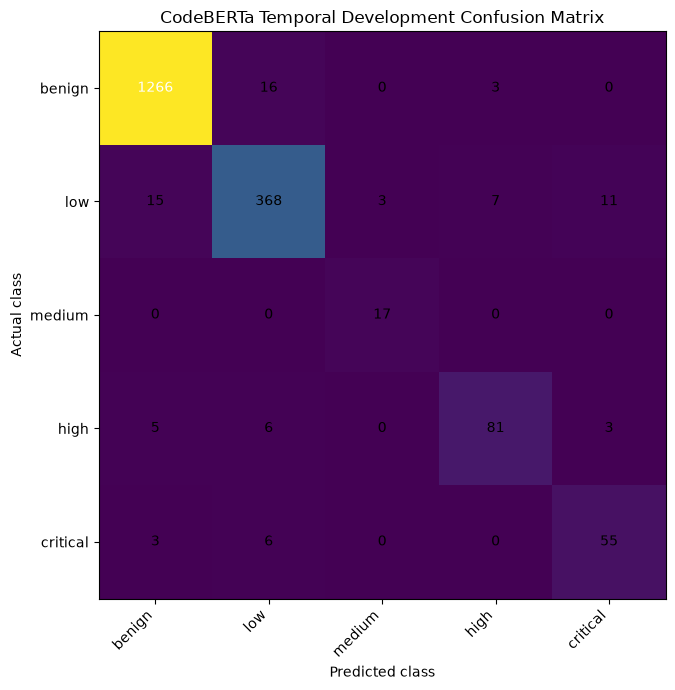

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\figures\transformer_confusion_matrix.png


In [36]:
plt.figure(figsize=(9, 7))

plt.imshow(
    transformer_confusion_matrix,
    interpolation="nearest",
)

plt.title(
    "CodeBERTa Temporal Development Confusion Matrix"
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.xticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
)

maximum_matrix_value = (
    transformer_confusion_matrix.max()
    if transformer_confusion_matrix.size
    else 0
)

text_threshold = (
    maximum_matrix_value / 2.0
)

for row_index in range(
    transformer_confusion_matrix.shape[0]
):
    for column_index in range(
        transformer_confusion_matrix.shape[1]
    ):
        matrix_value = (
            transformer_confusion_matrix[
                row_index,
                column_index,
            ]
        )

        plt.text(
            column_index,
            row_index,
            str(matrix_value),
            ha="center",
            va="center",
            color=(
                "white"
                if matrix_value
                > text_threshold
                else "black"
            ),
        )

plt.tight_layout()

transformer_confusion_figure_path = (
    FIGURES_DIR
    / "transformer_confusion_matrix.png"
)

plt.savefig(
    transformer_confusion_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    transformer_confusion_figure_path,
)

In [37]:
def calculate_expected_calibration_error(
    true_ids,
    probability_matrix,
    number_of_bins=15,
):
    predicted_ids = np.argmax(
        probability_matrix,
        axis=1,
    )

    confidences = np.max(
        probability_matrix,
        axis=1,
    )

    correctness = (
        predicted_ids
        == true_ids
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    expected_calibration_error = 0.0
    bin_records = []

    for bin_index in range(
        number_of_bins
    ):
        lower_edge = bin_edges[
            bin_index
        ]

        upper_edge = bin_edges[
            bin_index + 1
        ]

        if (
            bin_index
            == number_of_bins - 1
        ):
            in_bin = (
                confidences >= lower_edge
            ) & (
                confidences <= upper_edge
            )
        else:
            in_bin = (
                confidences >= lower_edge
            ) & (
                confidences < upper_edge
            )

        bin_count = int(
            in_bin.sum()
        )

        if bin_count == 0:
            continue

        bin_accuracy = float(
            correctness[
                in_bin
            ].mean()
        )

        bin_confidence = float(
            confidences[
                in_bin
            ].mean()
        )

        bin_weight = (
            bin_count
            / len(true_ids)
        )

        expected_calibration_error += (
            bin_weight
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

        bin_records.append(
            {
                "bin_lower": lower_edge,
                "bin_upper": upper_edge,
                "records": bin_count,
                "mean_confidence": (
                    bin_confidence
                ),
                "accuracy": (
                    bin_accuracy
                ),
                "absolute_gap": abs(
                    bin_accuracy
                    - bin_confidence
                ),
            }
        )

    return (
        float(
            expected_calibration_error
        ),
        pd.DataFrame(
            bin_records
        ),
    )


true_one_hot = np.eye(
    len(CLASS_ORDER)
)[transformer_true_ids]

multiclass_brier_score = float(
    np.mean(
        np.sum(
            (
                transformer_probability_matrix
                - true_one_hot
            ) ** 2,
            axis=1,
        )
    )
)

(
    expected_calibration_error,
    transformer_calibration_bins,
) = calculate_expected_calibration_error(
    true_ids=transformer_true_ids,
    probability_matrix=(
        transformer_probability_matrix
    ),
    number_of_bins=15,
)

print(
    "Multiclass log loss:",
    f"{transformer_log_loss:.4f}",
)

print(
    "Multiclass Brier score:",
    f"{multiclass_brier_score:.4f}",
)

print(
    "Expected calibration error:",
    f"{expected_calibration_error:.4f}",
)

display(
    transformer_calibration_bins
)

transformer_calibration_bins.to_csv(
    TABLES_DIR
    / "transformer_calibration_bins.csv",
    index=False,
)

Multiclass log loss: 0.2761
Multiclass Brier score: 0.0771
Expected calibration error: 0.0369


,bin_lower,bin_upper,records,mean_confidence,accuracy,absolute_gap
0,0.466667,0.533333,4,0.517407,0.750000,0.232593
1,0.533333,0.600000,3,0.566961,0.333333,0.233627
2,0.600000,0.666667,2,0.637902,0.500000,0.137902
3,0.666667,0.733333,6,0.698455,0.500000,0.198455
4,0.733333,0.800000,7,0.775406,0.714286,0.061120
5,0.800000,0.866667,7,0.823339,0.285714,0.537625
6,0.866667,0.933333,8,0.902778,0.625000,0.277778
7,0.933333,1.000000,1828,0.999068,0.966630,0.032438


In [38]:
transformer_prediction_output = (
    temporal_development_data[
        [
            "diff_id",
            "repository",
            "commit_hash",
            "commit_author_date",
            "file_path",
            "configuration_type",
            "parser_mode",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "training_target",
            "sample_weight",
        ]
    ]
    .copy()
)

transformer_prediction_output[
    "predicted_label"
] = transformer_predicted_labels

transformer_prediction_output[
    "prediction_correct"
] = (
    transformer_prediction_output[
        "training_target"
    ]
    == transformer_prediction_output[
        "predicted_label"
    ]
)

for class_index, class_name in enumerate(
    CLASS_ORDER
):
    transformer_prediction_output[
        f"probability_{class_name}"
    ] = (
        transformer_probability_matrix[
            :,
            class_index,
        ]
    )

transformer_prediction_output[
    "maximum_probability"
] = (
    transformer_probability_matrix.max(
        axis=1
    )
)

sorted_probability_matrix = np.sort(
    transformer_probability_matrix,
    axis=1,
)

transformer_prediction_output[
    "probability_margin"
] = (
    sorted_probability_matrix[
        :,
        -1,
    ]
    - sorted_probability_matrix[
        :,
        -2,
    ]
)

print(
    "Prediction-output records:",
    f"{len(transformer_prediction_output):,}",
)

display(
    transformer_prediction_output.head()
)

Prediction-output records: 1,865


,diff_id,repository,commit_hash,commit_author_date,file_path,configuration_type,parser_mode,operation,field_path,old_value,...,sample_weight,predicted_label,prediction_correct,probability_benign,probability_low,probability_medium,probability_high,probability_critical,maximum_probability,probability_margin
0,5312313a6a8671e134373e039b11e7051bf292e43aa6162ca76a21c07f99929c,kube_prometheus,760b786b29edb4aa917e87746cb9e2cab9cf3066,2025-09-15T10:37:32+02:00,manifests/setup/0servicemonitorCustomResourceDefinition.yaml,yaml,structured,modified,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.endpoints.items.properties.filterRunning.description,"When true, the pods which are not running (e.g. either in Failed or\nSucceeded state) are dropped during the target discovery.\n\nIf unset, the filtering is enabled.\n\nMore info: https://kubernetes.io/docs/concepts/workloads/pods/pod-lifecycle/#pod-phase",...,1.255671,high,False,0.001205,0.053422,0.000269,0.945081,0.000024,0.945081,0.891659
1,f56009fd0c56e99cbefde963be7533ee48cb222ea2db1c806114f6403f21b896,microservices_demo,18f3b732934abd656dc013bac7327a95c762b21c,2025-11-26T11:57:37-05:00,release/kubernetes-manifests.yaml,kubernetes,structured,modified,$.documents[19].spec.template.spec.containers[0].livenessProbe.grpc.port,7070,...,1.255671,low,True,0.000006,0.999970,0.000013,0.000004,0.000007,0.999970,0.999957
2,4363d09488d6d823688af9d432a3ca91ca73de992902ef6f4f976e570b43e107,microservices_demo,12b18767d5d7505aef4fe88b9ed3c9adbd4fd335,2025-07-24T19:38:03-04:00,src/currencyservice/package-lock.json,json,structured,added,$.packages.node_modules/call-bind-apply-helpers.resolved,NaN,...,9.600000,low,False,0.000003,0.999933,0.000010,0.000045,0.000009,0.999933,0.999887
3,2ecd8afa3913089561843c31d64520e2dc94eb220bda337bac8299c5f089a959,microservices_demo,7cfba453a014340f66c4b4963adfc0718858fd91,2025-05-29T21:56:03+03:00,helm-chart/values.yaml,helm,structured,modified,$.cartService.resources.limits.memory,128Mi,...,1.255671,low,True,0.000004,0.999924,0.000054,0.000004,0.000014,0.999924,0.999870
4,d2bb2e68d4656d2a8873d6838d9d2616ea03d8d6d3cba2604db4a021a92d753b,microservices_demo,abf56c68cee6d201e2b7f00e5848d49398a12de7,2025-10-14T15:38:39+01:00,src/paymentservice/package-lock.json,json,structured,deleted,$.dependencies.is-core-module.version,2.13.0,...,0.206497,benign,True,0.999973,0.000005,0.000011,0.000005,0.000006,0.999973,0.999962


In [39]:
critical_record_mask = (
    transformer_prediction_output[
        "training_target"
    ].eq("critical")
)

transformer_critical_false_negatives = (
    transformer_prediction_output[
        critical_record_mask
        &
        ~transformer_prediction_output[
            "predicted_label"
        ].eq("critical")
    ]
    .copy()
)

actual_high_critical_mask = (
    transformer_prediction_output[
        "training_target"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

predicted_high_critical_mask = (
    transformer_prediction_output[
        "predicted_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

transformer_high_critical_false_negatives = (
    transformer_prediction_output[
        actual_high_critical_mask
        &
        ~predicted_high_critical_mask
    ]
    .copy()
)

transformer_high_critical_false_positives = (
    transformer_prediction_output[
        ~actual_high_critical_mask
        &
        predicted_high_critical_mask
    ]
    .copy()
)

critical_record_count = int(
    critical_record_mask.sum()
)

print(
    "Critical temporal records:",
    f"{critical_record_count:,}",
)

print(
    "Critical false negatives:",
    f"{len(transformer_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(transformer_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(transformer_high_critical_false_positives):,}",
)

display(
    transformer_critical_false_negatives[
        [
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "predicted_label",
            "maximum_probability",
        ]
    ].head(20)
)

Critical temporal records: 64
Critical false negatives: 9
High/critical false negatives: 20
High/critical false positives: 21


,repository,configuration_type,operation,field_path,old_value,new_value,predicted_label,maximum_probability
56,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.endpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,low,0.998902
101,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.oauth2.properties.tokenUrl.minLength,1,NaN,benign,0.819028
139,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.podMetricsEndpoints.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,low,0.998384
587,kube_prometheus,yaml,added,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.volumes.items.properties.rbd.properties.user.default,NaN,admin,low,0.929203
1347,terraform_aws_vpc,terraform,added,$.module wrapper[0].default_network_acl_ingress[0],NaN,"try(each.value.default_network_acl_ingress, var.defaults.default_network_acl_ingress, [ { rule_no = 100 action = ""allow"" from_port = 0 to_port = 0 protocol = ""-1"" cidr_block = ""0.0.0.0/0"" }, { rule_no = 101 action = ""allow"" from_port = 0 to_port = 0 protocol = ""-1"" ipv6_cidr_block = ""::/0"" }, ])",low,0.880185
1407,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.alertmanagerConfiguration.properties.global.properties.httpConfig.properties.oauth2.properties.tokenUrl.minLength,1,NaN,low,0.954940
1478,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.httpSDConfigs.items.properties.proxyConnectHeader.additionalProperties.required[0],key,NaN,benign,0.978523
1737,kube_prometheus,yaml,deleted,$.spec.versions[0].schema.openAPIV3Schema.properties.spec.properties.remoteWrite.items.properties.oauth2.properties.tokenUrl.minLength,1,NaN,low,0.999513
1779,kube_prometheus,yaml,deleted,$.jobs.versions.steps[4].with.author,Prometheus Operator Bot <prom-op-bot@users.noreply.github.com>,NaN,benign,0.999945


In [40]:
transformer_misclassified_records = (
    transformer_prediction_output[
        ~transformer_prediction_output[
            "prediction_correct"
        ]
    ]
    .copy()
)

transformer_error_transitions = (
    transformer_misclassified_records
    .groupby(
        [
            "training_target",
            "predicted_label",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
    .sort_values(
        "records",
        ascending=False,
    )
)

print(
    "Misclassified records:",
    f"{len(transformer_misclassified_records):,}",
)

display(
    transformer_error_transitions.head(30)
)

transformer_error_transitions.to_csv(
    TABLES_DIR
    / "transformer_error_transitions.csv",
    index=False,
)

Misclassified records: 78


,training_target,predicted_label,records
1,benign,low,16
7,low,benign,15
8,low,critical,11
9,low,high,7
3,critical,low,6
6,high,low,6
4,high,benign,5
2,critical,benign,3
0,benign,high,3
5,high,critical,3


In [41]:
family_comparison_records = []

baseline_comparison_path = (
    BASELINE_OUTPUT_DIR
    / "tables"
    / "baseline_model_comparison.csv"
)

if baseline_comparison_path.exists():
    baseline_results = pd.read_csv(
        baseline_comparison_path
    )

    best_baseline_row = (
        baseline_results
        .sort_values(
            [
                "macro_f1",
                "critical_recall",
                "high_critical_recall",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

    family_comparison_records.append(
        {
            "model_family":
                "text_baseline",

            "model":
                best_baseline_row[
                    "model"
                ],

            "macro_f1": float(
                best_baseline_row[
                    "macro_f1"
                ]
            ),

            "balanced_accuracy": float(
                best_baseline_row[
                    "balanced_accuracy"
                ]
            ),

            "macro_pr_auc": float(
                best_baseline_row[
                    "macro_pr_auc"
                ]
            ),

            "critical_precision": float(
                best_baseline_row[
                    "critical_precision"
                ]
            ),

            "critical_recall": float(
                best_baseline_row[
                    "critical_recall"
                ]
            ),

            "high_critical_precision": float(
                best_baseline_row[
                    "high_critical_precision"
                ]
            ),

            "high_critical_recall": float(
                best_baseline_row[
                    "high_critical_recall"
                ]
            ),
        }
    )

structured_comparison_path = (
    STRUCTURED_OUTPUT_DIR
    / "tables"
    / "structured_model_comparison.csv"
)

if structured_comparison_path.exists():
    structured_results = pd.read_csv(
        structured_comparison_path
    )

    best_structured_row = (
        structured_results
        .sort_values(
            [
                "macro_f1",
                "critical_recall",
                "high_critical_recall",
            ],
            ascending=[
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

    family_comparison_records.append(
        {
            "model_family":
                "structured",

            "model":
                best_structured_row[
                    "model"
                ],

            "macro_f1": float(
                best_structured_row[
                    "macro_f1"
                ]
            ),

            "balanced_accuracy": float(
                best_structured_row[
                    "balanced_accuracy"
                ]
            ),

            "macro_pr_auc": float(
                best_structured_row[
                    "macro_pr_auc"
                ]
            ),

            "critical_precision": float(
                best_structured_row[
                    "critical_precision"
                ]
            ),

            "critical_recall": float(
                best_structured_row[
                    "critical_recall"
                ]
            ),

            "high_critical_precision": float(
                best_structured_row[
                    "high_critical_precision"
                ]
            ),

            "high_critical_recall": float(
                best_structured_row[
                    "high_critical_recall"
                ]
            ),
        }
    )

family_comparison_records.append(
    {
        "model_family": "transformer",

        "model": PRETRAINED_MODEL_NAME,

        "macro_f1": (
            transformer_overall_metrics[
                "macro_f1"
            ]
        ),

        "balanced_accuracy": (
            transformer_overall_metrics[
                "balanced_accuracy"
            ]
        ),

        "macro_pr_auc": (
            transformer_overall_metrics[
                "macro_pr_auc"
            ]
        ),

        "critical_precision": (
            transformer_overall_metrics[
                "critical_precision"
            ]
        ),

        "critical_recall": (
            transformer_overall_metrics[
                "critical_recall"
            ]
        ),

        "high_critical_precision": (
            transformer_overall_metrics[
                "high_critical_precision"
            ]
        ),

        "high_critical_recall": (
            transformer_overall_metrics[
                "high_critical_recall"
            ]
        ),
    }
)

model_family_comparison = (
    pd.DataFrame(
        family_comparison_records
    )
    .sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

model_family_comparison.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            model_family_comparison
        ) + 1,
    ),
)

display(
    model_family_comparison
)

best_overall_temporal_model = (
    model_family_comparison.iloc[0]
)

print(
    "Best temporal model family:",
    best_overall_temporal_model[
        "model_family"
    ],
)

print(
    "Best temporal model:",
    best_overall_temporal_model[
        "model"
    ],
)

,rank,model_family,model,macro_f1,balanced_accuracy,macro_pr_auc,critical_precision,critical_recall,high_critical_precision,high_critical_recall
0,1,transformer,huggingface/CodeBERTa-small-v1,0.904127,0.921622,0.949505,0.797101,0.859375,0.868750,0.874214
1,2,text_baseline,hybrid_linear_svm,0.899128,0.894573,0.916507,0.866667,0.812500,0.924658,0.849057
2,3,structured,structured_extra_trees,0.880329,0.873021,0.943107,0.927273,0.796875,0.860927,0.817610


Best temporal model family: transformer
Best temporal model: huggingface/CodeBERTa-small-v1


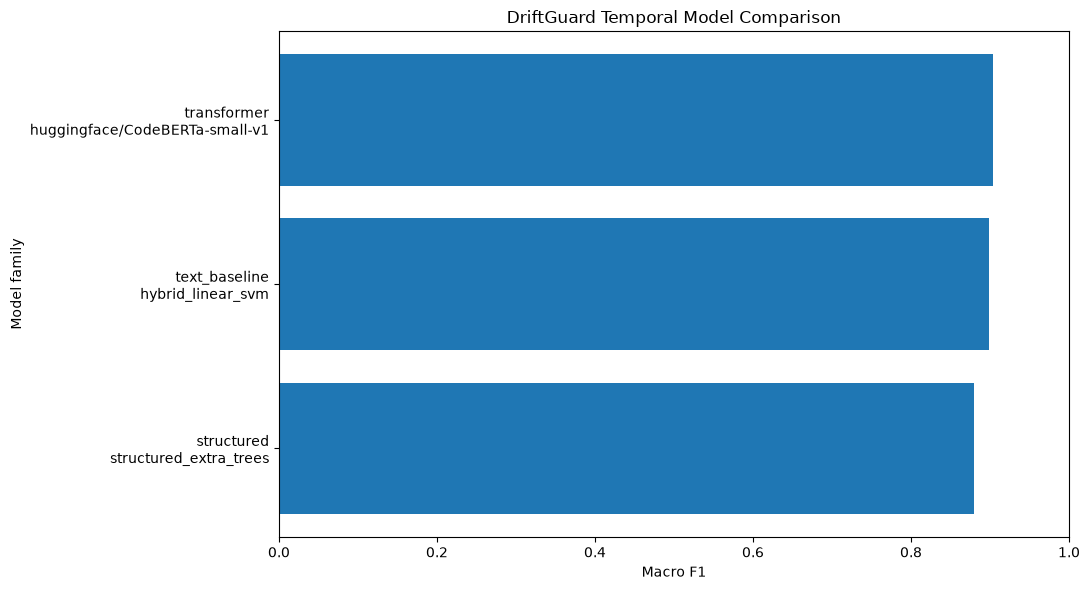

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\figures\temporal_model_family_comparison.png


In [42]:
comparison_plot_data = (
    model_family_comparison
    .sort_values(
        "macro_f1",
        ascending=True,
    )
)

comparison_labels = (
    comparison_plot_data[
        "model_family"
    ]
    + "\n"
    + comparison_plot_data[
        "model"
    ].astype(str)
)

plt.figure(figsize=(11, 6))

plt.barh(
    comparison_labels,
    comparison_plot_data[
        "macro_f1"
    ],
)

plt.title(
    "DriftGuard Temporal Model Comparison"
)

plt.xlabel("Macro F1")
plt.ylabel("Model family")

plt.xlim(
    0,
    max(
        1.0,
        comparison_plot_data[
            "macro_f1"
        ].max()
        * 1.10,
    ),
)

plt.tight_layout()

family_comparison_figure_path = (
    FIGURES_DIR
    / "temporal_model_family_comparison.png"
)

plt.savefig(
    family_comparison_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    family_comparison_figure_path,
)

In [43]:
transformer_metrics_path = (
    TABLES_DIR
    / "transformer_temporal_metrics.csv"
)

transformer_overall_metrics_df.to_csv(
    transformer_metrics_path,
    index=False,
)

family_comparison_path = (
    TABLES_DIR
    / "model_family_temporal_comparison.csv"
)

model_family_comparison.to_csv(
    family_comparison_path,
    index=False,
)

prediction_output_path = (
    PREDICTIONS_DIR
    / "transformer_temporal_predictions.csv.gz"
)

transformer_prediction_output.to_csv(
    prediction_output_path,
    index=False,
    compression="gzip",
)

critical_false_negative_path = (
    PREDICTIONS_DIR
    / "transformer_critical_false_negatives.csv.gz"
)

transformer_critical_false_negatives.to_csv(
    critical_false_negative_path,
    index=False,
    compression="gzip",
)

high_critical_false_negative_path = (
    PREDICTIONS_DIR
    / "transformer_high_critical_false_negatives.csv.gz"
)

transformer_high_critical_false_negatives.to_csv(
    high_critical_false_negative_path,
    index=False,
    compression="gzip",
)

print("Saved metrics        :", transformer_metrics_path)
print("Saved comparison     :", family_comparison_path)
print("Saved predictions    :", prediction_output_path)
print("Saved critical errors:", critical_false_negative_path)

Saved metrics        : C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\tables\transformer_temporal_metrics.csv
Saved comparison     : C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\tables\model_family_temporal_comparison.csv
Saved predictions    : C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\predictions\transformer_temporal_predictions.csv.gz
Saved critical errors: C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\predictions\transformer_critical_false_negatives.csv.gz


In [44]:
transformer_integrity_checks = {
    "Model-training data is not empty":
        len(
            model_training_data
        ) > 0,

    "Temporal-development data is not empty":
        len(
            temporal_development_data
        ) > 0,

    "Training and development commits are disjoint":
        len(
            overlapping_commit_keys
        ) == 0,

    "All five training classes exist":
        set(
            CLASS_ORDER
        ).issubset(
            set(
                model_training_data[
                    "training_target"
                ]
            )
        ),

    "All five development classes exist":
        set(
            CLASS_ORDER
        ).issubset(
            set(
                temporal_development_data[
                    "training_target"
                ]
            )
        ),

    "No forbidden raw feature is used":
        len(
            feature_leakage_overlap
        ) == 0,

    "Prediction count matches development data":
        len(
            transformer_prediction_output
        )
        == len(
            temporal_development_data
        ),

    "Predictions contain valid labels":
        transformer_prediction_output[
            "predicted_label"
        ].isin(
            CLASS_ORDER
        ).all(),

    "Probability rows sum to one":
        np.allclose(
            transformer_probability_matrix.sum(
                axis=1
            ),
            1.0,
            atol=1e-5,
        ),

    "Macro F1 is finite":
        np.isfinite(
            transformer_overall_metrics[
                "macro_f1"
            ]
        ),

    "Critical recall is finite":
        np.isfinite(
            transformer_overall_metrics[
                "critical_recall"
            ]
        ),

    "Best model directory exists":
        BEST_MODEL_DIR.exists(),

    "Model configuration exists":
        (
            BEST_MODEL_DIR
            / "config.json"
        ).exists(),

    "Tokenizer files exist":
        any(
            BEST_MODEL_DIR.glob(
                "tokenizer*"
            )
        ),

    "Temporal metrics output exists":
        transformer_metrics_path.exists(),

    "Prediction output exists":
        prediction_output_path.exists(),

    "Model-family comparison exists":
        family_comparison_path.exists(),
}

print("Transformer integrity checks:\n")

for check_name, passed in (
    transformer_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_transformer_checks = [
    check_name
    for check_name, passed
    in transformer_integrity_checks.items()
    if not bool(passed)
]

print(
    "\nFailed integrity checks:",
    len(
        failed_transformer_checks
    ),
)

Transformer integrity checks:

PASSED   | Model-training data is not empty
PASSED   | Temporal-development data is not empty
PASSED   | Training and development commits are disjoint
PASSED   | All five training classes exist
PASSED   | All five development classes exist
PASSED   | No forbidden raw feature is used
PASSED   | Prediction count matches development data
PASSED   | Predictions contain valid labels
PASSED   | Probability rows sum to one
PASSED   | Macro F1 is finite
PASSED   | Critical recall is finite
PASSED   | Best model directory exists
PASSED   | Model configuration exists
PASSED   | Tokenizer files exist
PASSED   | Temporal metrics output exists
PASSED   | Prediction output exists
PASSED   | Model-family comparison exists

Failed integrity checks: 0


In [45]:
transformer_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "pretrained_model":
        PRETRAINED_MODEL_NAME,

    "device":
        DEVICE_NAME,

    "cuda_available":
        CUDA_AVAILABLE,

    "gpu_memory_gb":
        GPU_MEMORY_GB,

    "model_training_records":
        int(
            len(
                model_training_data
            )
        ),

    "temporal_development_records":
        int(
            len(
                temporal_development_data
            )
        ),

    "model_training_commits":
        int(
            len(
                training_commit_keys
            )
        ),

    "temporal_development_commits":
        int(
            len(
                development_commit_keys
            )
        ),

    "maximum_sequence_length":
        MAXIMUM_SEQUENCE_LENGTH,

    "training_batch_size":
        TRAIN_BATCH_SIZE,

    "evaluation_batch_size":
        EVALUATION_BATCH_SIZE,

    "gradient_accumulation_steps":
        GRADIENT_ACCUMULATION_STEPS,

    "effective_batch_size":
        EFFECTIVE_BATCH_SIZE,

    "fp16":
        USE_FP16,

    "total_parameters":
        int(
            total_parameters
        ),

    "trainable_parameters":
        int(
            trainable_parameters
        ),

    "training_seconds":
        float(
            transformer_training_seconds
        ),

    "best_checkpoint":
        transformer_trainer.state.best_model_checkpoint,

    "best_monitored_metric": (
        None
        if transformer_trainer.state.best_metric
        is None
        else float(
            transformer_trainer.state.best_metric
        )
    ),

    "completed_epochs": (
        None
        if transformer_trainer.state.epoch
        is None
        else float(
            transformer_trainer.state.epoch
        )
    ),

    "temporal_metrics": {
        key: (
            float(value)
            if isinstance(
                value,
                (
                    np.floating,
                    float,
                    np.integer,
                    int,
                ),
            )
            else value
        )
        for key, value
        in transformer_overall_metrics.items()
    },

    "multiclass_brier_score":
        multiclass_brier_score,

    "expected_calibration_error":
        expected_calibration_error,

    "critical_false_negatives":
        int(
            len(
                transformer_critical_false_negatives
            )
        ),

    "high_critical_false_negatives":
        int(
            len(
                transformer_high_critical_false_negatives
            )
        ),

    "high_critical_false_positives":
        int(
            len(
                transformer_high_critical_false_positives
            )
        ),

    "best_overall_temporal_model": {
        key: (
            float(value)
            if isinstance(
                value,
                (
                    np.floating,
                    float,
                    np.integer,
                    int,
                ),
            )
            else value
        )
        for key, value
        in best_overall_temporal_model.to_dict().items()
    },

    "best_model_directory":
        str(
            BEST_MODEL_DIR
        ),

    "failed_integrity_checks":
        failed_transformer_checks,

    "all_integrity_checks_passed":
        len(
            failed_transformer_checks
        ) == 0,
}

transformer_summary_path = (
    OUTPUTS_DIR
    / "transformer_training_summary.json"
)

with transformer_summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        transformer_summary,
        file,
        indent=2,
    )

print(
    "Saved Transformer summary:",
    transformer_summary_path,
)

Saved Transformer summary: C:\Users\Lenovo\Desktop\DriftGuard\outputs\transformer_model\transformer_training_summary.json


In [46]:
print("=" * 72)
print("NOTEBOOK 09 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. HARDWARE AND TRAINING CONFIGURATION")
print("-" * 72)

print(
    "Device                      :",
    DEVICE_NAME,
)

print(
    "GPU memory                  :",
    f"{GPU_MEMORY_GB:.2f} GB",
)

print(
    "Pretrained model            :",
    PRETRAINED_MODEL_NAME,
)

print(
    "Maximum sequence length     :",
    MAXIMUM_SEQUENCE_LENGTH,
)

print(
    "Training batch size         :",
    TRAIN_BATCH_SIZE,
)

print(
    "Gradient accumulation steps :",
    GRADIENT_ACCUMULATION_STEPS,
)

print(
    "Effective batch size        :",
    EFFECTIVE_BATCH_SIZE,
)

print(
    "FP16                        :",
    USE_FP16,
)

print("\n2. DATASET USAGE")
print("-" * 72)

print(
    "Model-training records      :",
    f"{len(model_training_data):,}",
)

print(
    "Temporal-development records:",
    f"{len(temporal_development_data):,}",
)

print(
    "Model-training commits      :",
    f"{len(training_commit_keys):,}",
)

print(
    "Temporal-development commits:",
    f"{len(development_commit_keys):,}",
)

print(
    "Overlapping commits         :",
    f"{len(overlapping_commit_keys):,}",
)

print("\n3. TRANSFORMER TRAINING")
print("-" * 72)

print(
    "Total parameters      :",
    f"{total_parameters:,}",
)

print(
    "Trainable parameters  :",
    f"{trainable_parameters:,}",
)

print(
    "Training seconds      :",
    f"{transformer_training_seconds:.2f}",
)

print(
    "Completed epochs      :",
    transformer_trainer.state.epoch,
)

print(
    "Best monitored metric :",
    transformer_trainer.state.best_metric,
)

print(
    "Best checkpoint       :",
    transformer_trainer.state.best_model_checkpoint,
)

print("\n4. TEMPORAL-DEVELOPMENT RESULTS")
print("-" * 72)

display(
    transformer_overall_metrics_df[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "log_loss",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
        ]
    ]
)

print("\n5. PER-CLASS RESULTS")
print("-" * 72)

display(
    transformer_per_class_metrics
)

print("\n6. CALIBRATION")
print("-" * 72)

print(
    "Multiclass Brier score      :",
    f"{multiclass_brier_score:.4f}",
)

print(
    "Expected calibration error  :",
    f"{expected_calibration_error:.4f}",
)

print("\n7. SAFETY-CRITICAL ERRORS")
print("-" * 72)

print(
    "Critical false negatives     :",
    f"{len(transformer_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(transformer_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(transformer_high_critical_false_positives):,}",
)

print("\n8. MODEL-FAMILY COMPARISON")
print("-" * 72)

display(
    model_family_comparison
)

print(
    "Best temporal family:",
    best_overall_temporal_model[
        "model_family"
    ],
)

print(
    "Best temporal model :",
    best_overall_temporal_model[
        "model"
    ],
)

print("\n9. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_transformer_checks:
    for index, check_name in enumerate(
        failed_transformer_checks,
        start=1,
    ):
        print(
            f"{index}. {check_name}"
        )
else:
    print(
        "No failed integrity checks."
    )

    print(
        "All Transformer integrity checks passed."
    )

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 09 — REQUIRED RESULTS

1. HARDWARE AND TRAINING CONFIGURATION
------------------------------------------------------------------------
Device                      : NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory                  : 6.00 GB
Pretrained model            : huggingface/CodeBERTa-small-v1
Maximum sequence length     : 256
Training batch size         : 2
Gradient accumulation steps : 8
Effective batch size        : 16
FP16                        : True

2. DATASET USAGE
------------------------------------------------------------------------
Model-training records      : 7,711
Temporal-development records: 1,865
Model-training commits      : 1,058
Temporal-development commits: 266
Overlapping commits         : 0

3. TRANSFORMER TRAINING
------------------------------------------------------------------------
Total parameters      : 83,460,869
Trainable parameters  : 83,460,869
Training seconds      : 2109.10
Completed epochs      : 5.0
Best monitored metric : 0.9041274

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1
0,0.958177,0.921622,0.889732,0.921622,0.904127,0.958182,0.949505,0.276054,0.797101,0.859375,0.827068,0.86875,0.874214,0.871473



5. PER-CLASS RESULTS
------------------------------------------------------------------------


,class,support,precision,recall,f1,average_precision
0,benign,1285,0.982157,0.985214,0.983683,0.997085
1,low,404,0.929293,0.910891,0.920000,0.969973
2,medium,17,0.850000,1.000000,0.918919,0.981889
3,high,95,0.890110,0.852632,0.870968,0.926292
4,critical,64,0.797101,0.859375,0.827068,0.872289



6. CALIBRATION
------------------------------------------------------------------------
Multiclass Brier score      : 0.0771
Expected calibration error  : 0.0369

7. SAFETY-CRITICAL ERRORS
------------------------------------------------------------------------
Critical false negatives     : 9
High/critical false negatives: 20
High/critical false positives: 21

8. MODEL-FAMILY COMPARISON
------------------------------------------------------------------------


,rank,model_family,model,macro_f1,balanced_accuracy,macro_pr_auc,critical_precision,critical_recall,high_critical_precision,high_critical_recall
0,1,transformer,huggingface/CodeBERTa-small-v1,0.904127,0.921622,0.949505,0.797101,0.859375,0.868750,0.874214
1,2,text_baseline,hybrid_linear_svm,0.899128,0.894573,0.916507,0.866667,0.812500,0.924658,0.849057
2,3,structured,structured_extra_trees,0.880329,0.873021,0.943107,0.927273,0.796875,0.860927,0.817610


Best temporal family: transformer
Best temporal model : huggingface/CodeBERTa-small-v1

9. FAILED INTEGRITY CHECKS
------------------------------------------------------------------------
No failed integrity checks.
All Transformer integrity checks passed.

REQUIRED RESULTS GENERATED


In [47]:
print("=" * 72)
print("NOTEBOOK 09 COMPLETED")
print("=" * 72)

print(
    "Transformer model:",
    PRETRAINED_MODEL_NAME,
)

print(
    "Temporal macro F1:",
    f"{transformer_overall_metrics['macro_f1']:.4f}",
)

print(
    "Temporal balanced accuracy:",
    f"{transformer_overall_metrics['balanced_accuracy']:.4f}",
)

print(
    "Temporal macro PR-AUC:",
    f"{transformer_overall_metrics['macro_pr_auc']:.4f}",
)

print(
    "Critical precision:",
    f"{transformer_overall_metrics['critical_precision']:.4f}",
)

print(
    "Critical recall:",
    f"{transformer_overall_metrics['critical_recall']:.4f}",
)

print(
    "High/critical precision:",
    f"{transformer_overall_metrics['high_critical_precision']:.4f}",
)

print(
    "High/critical recall:",
    f"{transformer_overall_metrics['high_critical_recall']:.4f}",
)

print(
    "Critical false negatives:",
    f"{len(transformer_critical_false_negatives):,}",
)

print(
    "Best temporal model family:",
    best_overall_temporal_model[
        "model_family"
    ],
)

print(
    "Best temporal model:",
    best_overall_temporal_model[
        "model"
    ],
)

print(
    "Saved Transformer model:",
    BEST_MODEL_DIR,
)

print("\nImportant:")
print("- Only temporal model-training records were used for fitting.")
print("- Temporal-development commits remained disjoint.")
print("- Validation and test repositories were not loaded.")
print("- Weak-label rules and explanations were excluded from input.")
print("- Sample weights were incorporated into the Transformer loss.")
print("- These remain weak-label temporal-development metrics.")
print("- Notebook 10 will perform repository-disjoint evaluation.")

print("\nNext notebook:")
print("10_repository_disjoint_evaluation.ipynb")

NOTEBOOK 09 COMPLETED
Transformer model: huggingface/CodeBERTa-small-v1
Temporal macro F1: 0.9041
Temporal balanced accuracy: 0.9216
Temporal macro PR-AUC: 0.9495
Critical precision: 0.7971
Critical recall: 0.8594
High/critical precision: 0.8688
High/critical recall: 0.8742
Critical false negatives: 9
Best temporal model family: transformer
Best temporal model: huggingface/CodeBERTa-small-v1
Saved Transformer model: C:\Users\Lenovo\Desktop\DriftGuard\models\transformer\best_codeberta_model

Important:
- Only temporal model-training records were used for fitting.
- Temporal-development commits remained disjoint.
- Validation and test repositories were not loaded.
- Weak-label rules and explanations were excluded from input.
- Sample weights were incorporated into the Transformer loss.
- These remain weak-label temporal-development metrics.
- Notebook 10 will perform repository-disjoint evaluation.

Next notebook:
10_repository_disjoint_evaluation.ipynb
